In [1]:
import wrf
import cartopy.crs as ccrs
import netCDF4 as nc
import glob
import numpy as np
import xarray as xr
import datetime as dt
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import matplotlib.ticker as mticker

from matplotlib.cm import get_cmap
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Rectangle
from matplotlib import colors

from cartopy import geodesic
from cartopy.feature import NaturalEarthFeature, BORDERS, ShapelyFeature, OCEAN, LAND
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.shapereader as shpreader
import shapely
from shapely.geometry.polygon import Polygon


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [14]:
# Paths
path_outputs = "/g/data/w28/ai2733/" # WRF outputs
path_save    = "/g/data/up6/ai2733/Gusts_downdrafts/data/"
path_figs    = "/g/data/up6/ai2733/Gusts_downdrafts/figures/Figures/"
path_domains = "/g/data/up6/ai2733/Gusts_downdrafts/data/wps_domains/"


In [10]:
# General info
lat_lon_cases = {"CASE1": (-29.49, 149.85), 
                "CASE2_new": (-35.16, 147.46), 
                 "CASE3_new": (-31.07,150.84)}
name_cases    = {"CASE1": "Moree Aero",
                 "CASE2_new": "Wagga Wagga", 
                 "CASE3_new": "Tamworth Airport"}

## Read AWS

In [11]:
cases = ["CASE1", "CASE2_new", "CASE3_new"]
df_aws     = {}
for case in cases:
    df_aws[case] = pd.read_csv(f"{path_save}/AWS/AWS_{case}.csv", index_col = 0, parse_dates = True)

## Read WRF outputs

In [12]:
# Find the indexes of the files between dates: to save memory when reading the files
def find_idx_file(dom, date_i, date_f): # Dates have to be exact
    list_files = np.sort(glob.glob(f"{path_wrf}wrfout_{dom}_*"))
    idx_ti = list(list_files).index(f'{path_wrf}wrfout_{dom}_{date_i}') 
    try:
        idx_tf = list(list_files).index(f'{path_wrf}wrfout_{dom}_{date_f}') 
    except: 
        idx_tf = -1
    return (int(idx_ti), int(idx_tf))

dates_filter_cases = {"CASE1":{"d01":("2015-12-16_00:00:00", "2015-12-16_12:00:00"),
                              "d02":("2015-12-16_00:05:00", "2015-12-16_11:35:00"),
                              "d03":("2015-12-16_00:05:00", "2015-12-16_11:35:00")},
                     "CASE2_new":{"d01":("2009-01-20_00:00:00", "2009-01-20_12:00:00"),
                              "d02":("2009-01-20_00:05:00", "2009-01-20_12:05:00"),
                              "d03":("2009-01-20_00:05:00", "2009-01-20_12:05:00")},
                     "CASE3_new":{"d01":("2017-02-17_00:00:00", "2017-02-17_12:00:00"),
                              "d02":("2017-02-17_00:05:00", "2017-02-17_12:35:00"),
                              "d03":("2017-02-17_00:05:00", "2017-02-17_12:35:00")}}


In [13]:
def latlon_dist(lat, lon, lats, lons):

    #Function from mr: Calculate great circle distance (Harversine) between a lat lon point (lat, lon) and a list of lat lon
    # points (lats, lons)

    R = 6373.0

    lat1 = np.deg2rad(lat)
    lon1 = np.deg2rad(lon)
    lat2 = np.deg2rad(lats)
    lon2 = np.deg2rad(lons)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return (R * c)

In [15]:
# Read WRF outputs
domains = ["d01", "d02", "d03"]
color_domains = {"d01":"dodgerblue", "d02":"orange", "d03":"green"}
wrflist = {}
wrf_all = {}
speed_max, speed_max_rad, downspeed_max, upspeed_max = {}, {}, {}, {}
extent_d3 = {}

for case in cases:
    path_wrf = f"{path_outputs}/outputs_{case}/"
    
    # Read WRF domains
    with open(f'{path_domains}/extent_d3.pkl', 'rb') as f:
        extent_d3 = pickle.load(f)[case]
        
    # Load all outputs: I already excluded spinup times in diff dir
    for dom in domains: wrflist[f"{case}_{dom}"] = [nc.Dataset(f) for f in np.sort(glob.glob(f"{path_wrf}wrfout_{dom}_*"))]

    # Print times
    times_d3 = wrf.extract_times(wrflist[f"{case}_d03"],wrf.ALL_TIMES)

    # Find index of files to look at
    idx_dom = {}
    for dom in domains:
        di, df = dates_filter_cases[case][dom]
        idx_dom[dom] = find_idx_file(dom, di, df)

    # Get variables between times of interest
    vars_all = ["WSPD10MAX"]#, "wa"] #"U10", "V10"] #"WSPD10MAX", "W"]#, "REFL_10CM"]#"WSPD10MAX"]#, "REFL_10CM"]#, "W", 
    for var in vars_all:
        wrf_all[f"{case}_{var}"]  = {}
        for dom in domains:
            ti, tf = idx_dom[dom]
            aux_ = wrf.getvar(wrflist[f"{case}_{dom}"][ti:tf] if tf == -1 else wrflist[f"{case}_{dom}"][ti:tf+1], var, timeidx=wrf.ALL_TIMES, method="cat")
            # Remove duplicates
            wrf_all[f"{case}_{var}"][dom] = aux_.drop_duplicates("Time", keep='last')
            del aux_
        print (var, "read")

    # Get maximums ws in various neighbourhood from WRF: to plot
    rad = 15
    lat, lon = lat_lon_cases[case]
    print (f"looking for max at {rad}km radius from {lat}, {lon}")
    for dom in domains:
        dist = latlon_dist(lat, lon, 
                    wrf.getvar(wrflist[f"{case}_{dom}"], "XLAT", timeidx=0).values, 
                    wrf.getvar(wrflist[f"{case}_{dom}"], "XLONG", timeidx=0).values)
        speed_max[f"{case}_{dom}"]     = xr.where(dist<=rad, wrf_all[f"{case}_WSPD10MAX"][dom], np.nan)
        speed_max_rad[f"{case}_{dom}"] = speed_max[f"{case}_{dom}"].max(("south_north","west_east")).to_dataframe(name="speed")

    print (case, " done")

WSPD10MAX read
looking for max at 15km radius from -29.49, 149.85
CASE1  done
WSPD10MAX read
looking for max at 15km radius from -35.16, 147.46
CASE2_new  done
WSPD10MAX read
looking for max at 15km radius from -31.07, 150.84
CASE3_new  done


In [7]:
# Get time of maxima ws
time_ws_max  = {}
coords_ws_max = {}
serie_ws_max = {}
position_ws_max = {}
for case in cases:
    for dom in domains:
        value_max = speed_max[f"{case}_{dom}"].max(("south_north","west_east")).to_dataframe().WSPD10MAX.max()
        time_max  = speed_max[f"{case}_{dom}"].max(("south_north","west_east")).to_dataframe().WSPD10MAX.idxmax()

        print (f"Max ws at {dom} at {time_max}: {np.round(value_max,2)} m/s")
        time_ws_max[f"{case}_{dom}"] = time_max
        # All data in that time 
        aux_ws = speed_max[f"{case}_{dom}"].sel(Time = time_max)
        # Get pixel 
        aux_ws2 = aux_ws.where(aux_ws==aux_ws.max(), drop=True).squeeze()
        lon_max, lat_max = aux_ws2.XLONG.item(), aux_ws2.XLAT.item()
        coords_ws_max[f"{case}_{dom}"] = [lon_max, lat_max]
        # Get position
        x_max, y_max = wrf.ll_to_xy(wrflist[f"{case}_{dom}"][0], latitude = lat_max, longitude = lon_max)
        position_ws_max[f"{case}_{dom}"] = [x_max.item(), y_max.item()]
        serie_ws_max[f"{case}_{dom}"]    =  speed_max[f"{case}_{dom}"].sel({"south_north":y_max, "west_east":x_max}).to_pandas()

Max ws at d01 at 2015-12-16 08:00:00: 14.27 m/s
Max ws at d02 at 2015-12-16 06:40:00: 18.31 m/s
Max ws at d03 at 2015-12-16 07:30:00: 26.78 m/s
Max ws at d01 at 2009-01-20 05:00:00: 11.38 m/s
Max ws at d02 at 2009-01-20 07:35:00: 22.51 m/s
Max ws at d03 at 2009-01-20 05:10:00: 31.74 m/s
Max ws at d01 at 2017-02-17 09:00:00: 12.81 m/s
Max ws at d02 at 2017-02-17 08:00:00: 16.61 m/s
Max ws at d03 at 2017-02-17 08:05:00: 23.71 m/s


## Figure 7: observed and WRF simulated gust

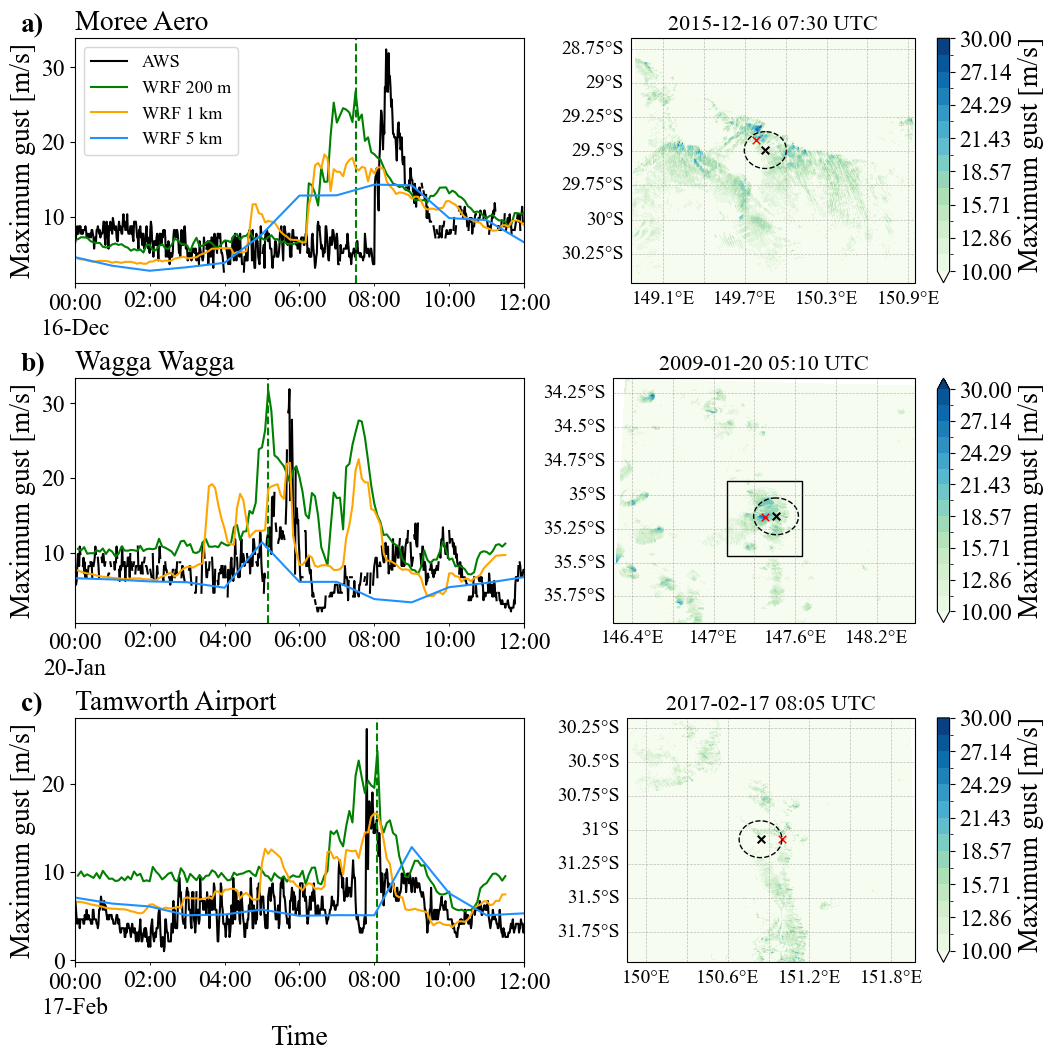

In [9]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))  # no projection
fs = 20
plt.rcParams.update({
    "font.size": fs,
    "axes.titlesize": fs,
    "axes.labelsize": fs,
    "xtick.labelsize": fs-3,
    "ytick.labelsize": fs-3,
    "legend.fontsize": fs-2,
    "figure.titlesize": fs+2,
    "font.family": "Times New Roman",
})

plot_aws = True
domains = ["d01", "d02", "d03"]
res_dom = {"d03": "200 m", "d02": "1 km", "d01": "5 km"}

xlim = [["2015-12-16 00:00", "2015-12-16 12:00"],
        ["2009-01-20 00:00", "2009-01-20 12:00"],
        ["2017-02-17 00:00", "2017-02-17 12:00"]]

labels = ['a)', 'b)', 'c)']

for i in range(3):
    case = cases[i]
    rad = 20 if case == "CASE1" else 15
    rad = 15
    
    # LEFT COLUMN (time series)
    ax_ts = axes[i, 0]
    aws_serie = (df_aws[case]["max_ws[km/h]"] / 3.6)
    aws_serie.loc[xlim[i][0]: xlim[i][1]].plot(ax=ax_ts, color="k", label='AWS')

    for dom in domains[::-1]: 
        df_plot = speed_max_rad[f"{case}_{dom}"].speed
    
        df_plot.loc[xlim[i][0]: xlim[i][1]].plot(
            ax=ax_ts, color=color_domains[dom],
            label=f'WRF {res_dom[dom]}' )
        
        if dom == "d03":
            ax_ts.axvline(x = time_ws_max[f"{case}_{dom}"], ls = "--", c = "green")

    if i != 2:
        ax_ts.set_xlabel("")
    ax_ts.set_ylabel("Maximum gust [m/s]")
    ax_ts.set_title(name_cases[case], loc="left")
    ax_ts.text(-0.12, 1.1, labels[i], transform=ax_ts.transAxes,
               fontsize=20, fontweight="bold", va="top")
    ax_ts.legend(loc='upper left', fontsize=13)

    if i > 0:
        ax_ts.legend_.remove()

    # RIGHT COLUMN (maps)
    fig.delaxes(axes[i, 1])  
    ax_map = fig.add_subplot(3, 2, 2*i+2, projection=ccrs.PlateCarree())
    ax_map.tick_params(labelsize=10)

    dom = "d03"
    ws = wrf_all[f"{case}_WSPD10MAX"][dom].sel(Time=time_ws_max[f"{case}_{dom}"], method="nearest")

    plot = ws.plot(ax=ax_map, x="XLONG", y="XLAT", cmap="GnBu", vmin=10, vmax=30,
                   levels=15, cbar_kwargs={"label": "Maximum gust [m/s]", "shrink": 1.0})

    coords_max = coords_ws_max[f"{case}_{dom}"]
    ax_map.scatter(coords_max[0],coords_max[1], marker = "x", facecolor = "red", linewidths = 1.0, s = 30.) 
        
    if plot_aws:
        lat_aws, lon_aws = lat_lon_cases[case]
        circle_points = geodesic.Geodesic().circle(lon_aws, lat_aws, rad * 1000)
        geom = shapely.geometry.Polygon(circle_points)
        ax_map.scatter(lon_aws, lat_aws, marker="x", color="black", s=30)
        ax_map.add_geometries([geom], crs=ccrs.PlateCarree(), facecolor='none', edgecolor="black", linestyle="--", linewidth=1.0)

    if i == 1: # For case 2
        extent_plots = [147.1, 147.65, -35.45, -34.9]
        lon_min, lon_max, lat_min, lat_max = extent_plots
        width = lon_max - lon_min
        height = lat_max - lat_min

        rect = Rectangle((lon_min, lat_min), width, height,
                                  linewidth=1, edgecolor='black', facecolor='none',
                                  transform=ccrs.PlateCarree())

        ax_map.add_patch(rect) 
    
    
    ax_map.coastlines()
    ax_map.set_extent(extent_d3[case])
    gl = ax_map.gridlines(crs=ccrs.PlateCarree(), x_inline=False, y_inline=False,
                          draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    gl.xlabel_style = {"size": 14}
    gl.ylabel_style = {"size": 14}
    
    try:
        title_ = str(ax_map.title).split("Time = ")[1].split(",")[0].replace("T", " ")[:-3] + " UTC"
        ax_map.set_title(title_, size=16)
    except:
        pass

plt.subplots_adjust(hspace=0.39, wspace=0.07)
plt.savefig(f"{path_figs}/Figure7.png", dpi = 300, bbox_inches = "tight")
plt.show()